# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test2 geometry

Notebook equivalent of `tests/4_earth/test2_geometry.py`. The original Python test module remains the source of truth; this notebook imports it and runs each numerical test and diagnostic plot in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated `earth` test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original `earth` test module, and reloads it so source changes are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing import paths for the editable package.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test2_geometry"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "4_earth" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\4_earth\test2_geometry.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes `earth` test figures and generated artifacts under `OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots follow the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "earth" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\earth\test2_geometry


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_detector_radius_fraction_surface`

**What is checked:** Detector radius fraction surface behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: 1.0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [4]:
run_notebook_test(TEST_MODULE.test_detector_radius_fraction_surface)


Running test_detector_radius_fraction_surface ...

Detector radius fraction at surface:
depth_m = 0.0
r_d     = 1.0
------------------------------------------------------------------------------------------
PASSED: test_detector_radius_fraction_surface


## Test: `test_detector_radius_fraction_depth`

**What is checked:** Detector radius fraction depth behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: assert_close.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [5]:
run_notebook_test(TEST_MODULE.test_detector_radius_fraction_depth)


Running test_detector_radius_fraction_depth ...

Detector radius fraction at depth:
depth_m  = 1000.0
R_E      = 6371000.0
r_d      = 0.9998430387694239
expected = 0.9998430387694239
------------------------------------------------------------------------------------------
PASSED: test_detector_radius_fraction_depth


## Test: `test_eta_prime_surface_identity`

**What is checked:** Eta prime surface identity behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: For r_d=1 and eta in [0, pi/2], eta_prime should equal eta..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [6]:
run_notebook_test(TEST_MODULE.test_eta_prime_surface_identity)


Running test_eta_prime_surface_identity ...

eta_prime at surface:
max|eta_prime - eta| = 2.220446049250313e-16
------------------------------------------------------------------------------------------
PASSED: test_eta_prime_surface_identity


## Test: `test_eta_prime_depth_is_smaller`

**What is checked:** Eta prime depth is smaller behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: For r_d<1, eta_prime should be <= eta in [0, pi/2]..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [7]:
run_notebook_test(TEST_MODULE.test_eta_prime_depth_is_smaller)


Running test_eta_prime_depth_is_smaller ...

eta_prime at depth:
min eta_prime - eta = -0.01771708891420798
max eta_prime - eta = 0.0
------------------------------------------------------------------------------------------
PASSED: test_eta_prime_depth_is_smaller


## Test: `test_detector_x_coordinate`

**What is checked:** Detector x coordinate behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: x_d should equal r_d cos(eta)..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [8]:
run_notebook_test(TEST_MODULE.test_detector_x_coordinate)


Running test_detector_x_coordinate ...

Detector x-coordinate:
eta      = tensor([0.0000000000e+00, 7.8539816340e-01, 1.5707963268e+00], device='cuda:0', dtype=torch.float64)
x_d      = tensor([1.0000000000e+00, 7.0710678119e-01, 6.1232339957e-17], device='cuda:0', dtype=torch.float64)
expected = tensor([1.0000000000e+00, 7.0710678119e-01, 6.1232339957e-17], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_detector_x_coordinate


## Test: `test_chord_length_case_b_surface`

**What is checked:** Chord length case b surface behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Chord length contains NaN or Inf.; Chord length should be non-negative up to numerical tolerance.; 0.0.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [9]:
run_notebook_test(TEST_MODULE.test_chord_length_case_b_surface)


Running test_chord_length_case_b_surface ...

Case-B chord length at surface:
min dx = -9.575673587391975e-16
max dx = 2.2343238370581275e-15
------------------------------------------------------------------------------------------
PASSED: test_chord_length_case_b_surface


## Test: `test_chord_length_case_b_depth`

**What is checked:** Chord length case b depth behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Chord length contains NaN or Inf.; Chord length should be non-negative up to numerical tolerance..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [10]:
run_notebook_test(TEST_MODULE.test_chord_length_case_b_depth)


Running test_chord_length_case_b_depth ...

Case-B chord length at detector depth:
min dx = 0.00015696123057606925
max dx = 0.01771716185861126
------------------------------------------------------------------------------------------
PASSED: test_chord_length_case_b_depth


## Test: `test_classify_eta_regions_surface`

**What is checked:** Classify eta regions surface behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: At depth=0, eta>=pi/2 should be above horizon.; eta<pi/2 should be Case A.; At depth=0, above-horizon values should not be Case B..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [11]:
run_notebook_test(TEST_MODULE.test_classify_eta_regions_surface)


Running test_classify_eta_regions_surface ...

Region classification at surface:
eta    = tensor([0.0000000000e+00, 4.0000000000e-01, 1.5707963268e+00, 2.0000000000e+00, 3.1415926536e+00], device='cuda:0', dtype=torch.float64)
above  = tensor([False, False,  True,  True,  True], device='cuda:0')
mask A = tensor([ True,  True, False, False, False], device='cuda:0')
mask B = tensor([False, False, False, False, False], device='cuda:0')
------------------------------------------------------------------------------------------
PASSED: test_classify_eta_regions_surface


## Test: `test_classify_eta_regions_depth`

**What is checked:** Classify eta regions depth behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: At depth>0 there should be no above-horizon identity mask.; eta<pi/2 should be Case A.; eta>=pi/2 should be Case B..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [12]:
run_notebook_test(TEST_MODULE.test_classify_eta_regions_depth)


Running test_classify_eta_regions_depth ...

Region classification at depth:
eta    = tensor([0.0000000000e+00, 4.0000000000e-01, 1.5707963268e+00, 2.0000000000e+00, 3.1415926536e+00], device='cuda:0', dtype=torch.float64)
above  = tensor([False, False, False, False, False], device='cuda:0')
mask A = tensor([ True,  True, False, False, False], device='cuda:0')
mask B = tensor([False, False,  True,  True,  True], device='cuda:0')
------------------------------------------------------------------------------------------
PASSED: test_classify_eta_regions_depth


## Test: `test_validate_eta_range_valid`

**What is checked:** Validate eta range valid behavior and numerical consistency.

**Expected result:** The expected result is a clean pass for these checks: Valid eta range accepted..

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [13]:
run_notebook_test(TEST_MODULE.test_validate_eta_range_valid)


Running test_validate_eta_range_valid ...

Validating eta range [0, pi]
------------------------------------------------------------------------------------------
PASSED: test_validate_eta_range_valid


## Test: `test_validate_eta_range_invalid_low`

**What is checked:** Validate eta range invalid low behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [14]:
run_notebook_test(TEST_MODULE.test_validate_eta_range_invalid_low)


Running test_validate_eta_range_invalid_low ...

Validating invalid eta range, low value:
tensor([-1.0000000000e-01, 2.0000000000e-01], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_validate_eta_range_invalid_low


## Test: `test_validate_eta_range_invalid_high`

**What is checked:** Validate eta range invalid high behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check.


In [15]:
run_notebook_test(TEST_MODULE.test_validate_eta_range_invalid_high)


Running test_validate_eta_range_invalid_high ...

Validating invalid eta range, high value:
tensor([2.0000000000e-01, 3.2415926536e+00], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_validate_eta_range_invalid_high


## Plot: `plot_eta_prime_transformation()`

**What is checked:** Eta prime transformation behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_geometry_eta_prime.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_eta_prime_transformation()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_geometry_eta_prime.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_eta_prime_transformation() ...
Saved plot: V:\output\test\earth\test2_geometry\plot_eta_prime_transformation_figure_001.png


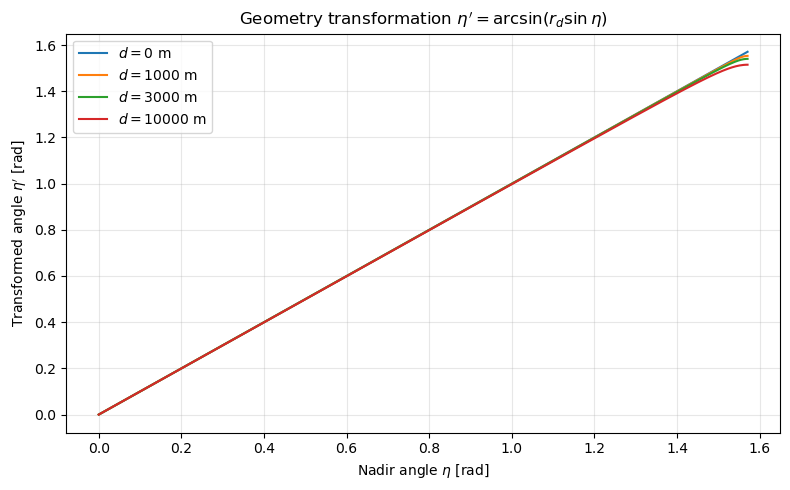

PASSED: plot_eta_prime_transformation()


In [16]:
run_notebook_call('plot_eta_prime_transformation()', lambda: TEST_MODULE.plot_eta_prime_transformation())


## Plot: `plot_detector_x_coordinate()`

**What is checked:** Detector x coordinate behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_geometry_detector_x.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_detector_x_coordinate()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_geometry_detector_x.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_detector_x_coordinate() ...
Saved plot: V:\output\test\earth\test2_geometry\plot_detector_x_coordinate_figure_001.png


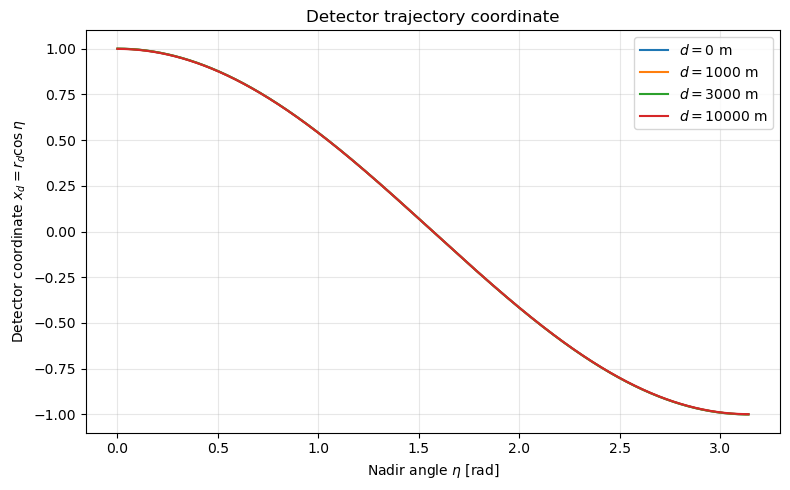

PASSED: plot_detector_x_coordinate()


In [17]:
run_notebook_call('plot_detector_x_coordinate()', lambda: TEST_MODULE.plot_detector_x_coordinate())


## Plot: `plot_case_b_chord_length()`

**What is checked:** Case b chord length behavior and numerical consistency.

**Expected result:** The expected result is that the plot call writes its diagnostic image file(s) (earth_geometry_case_b_chord.png) to `OUTPUT_DIR` and displays them inline when `SHOW_PLOTS = True`.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; earth-density, exposure-cache, or geometry convention changes can affect this check; missing or blank plots may indicate a path, backend, or non-finite numerical-data problem.


### Plot output for `plot_case_b_chord_length()`

This block generates or validates diagnostic plot files in `OUTPUT_DIR`:

- `earth_geometry_case_b_chord.png`

The expected result is that each image is written to disk and, when `SHOW_PLOTS = True`, also displayed inline in the notebook. Possible problems include a non-writable output directory, an inactive Matplotlib backend, or upstream numerical values that make the plotted curves empty or non-finite.


Running plot_case_b_chord_length() ...
Saved plot: V:\output\test\earth\test2_geometry\plot_case_b_chord_length_figure_001.png


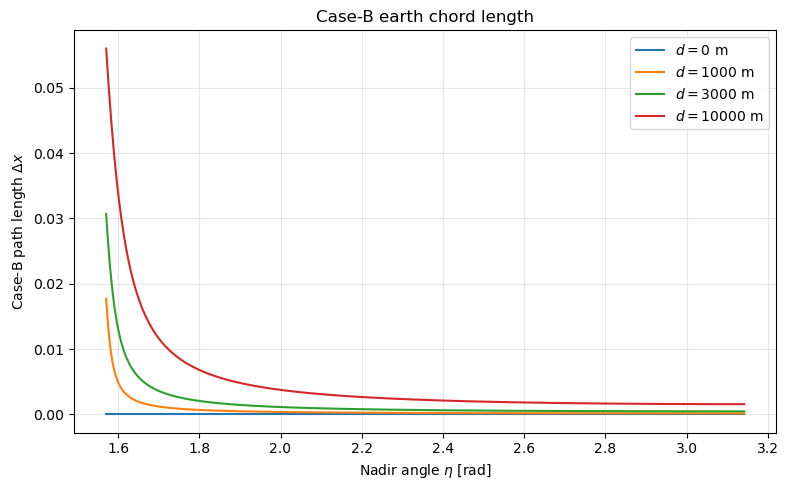

PASSED: plot_case_b_chord_length()


In [18]:
run_notebook_call('plot_case_b_chord_length()', lambda: TEST_MODULE.plot_case_b_chord_length())
